In [ ]:
# ============================================================
# BLOOD DONATION ELIGIBILITY PREDICTION
# Random Forest Classification
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [ ]:
# ------------------------------------------------------------
# Load Dataset
# ------------------------------------------------------------

data = pd.read_csv("/content/archive (4).zip")

print("\nDataset Shape:")
print(data.shape)

print("\nFirst 5 Rows:")
print(data.head())


Dataset Shape:
(10000, 18)

First 5 Rows:
    Donor_ID       Full_Name  Gender  Age Blood_Group  Contact_Number  \
0  DNR000001  Sangeeta Menon  Female   38          O+      1819600042   
1  DNR000002      Meena Iyer  Female   49          B+       265423420   
2  DNR000003      Priya Nair  Female   29          B+      1849593012   
3  DNR000004    Vijay Kapoor    Male   29          O+      3419283185   
4  DNR000005      Rahul Iyer    Male   27          A+      6413953676   

                          Email                City           State Country  \
0  sangeeta.menon8280@gmail.com             Kolkata     West Bengal   India   
1      meena.iyer6225@gmail.com              Jaipur       Rajasthan   India   
2      priya.nair4742@gmail.com             Gurgaon         Haryana   India   
3    vijay.kapoor4423@gmail.com  Thiruvananthapuram          Kerala   India   
4      rahul.iyer2341@gmail.com              Bhopal  Madhya Pradesh   India   

  Last_Donation_Date  Total_Donations Eligi

In [ ]:
# ------------------------------------------------------------
# Check Missing Values
# ------------------------------------------------------------

print("\nMissing Values:")
print(data.isnull().sum())



Missing Values:
Donor_ID                    0
Full_Name                   0
Gender                      0
Age                         0
Blood_Group                 0
Contact_Number              0
Email                       0
City                        0
State                       0
Country                     0
Last_Donation_Date          0
Total_Donations             0
Eligible_for_Donation       0
Medical_Condition        7805
Weight_kg                   0
Hemoglobin_g_dL             0
Donation_Center             0
Registration_Date           0
dtype: int64


In [ ]:
# ------------------------------------------------------------
#  Target Variable
# ------------------------------------------------------------

target = "Eligible_for_Donation"

print("\nTarget Distribution:")
print(data[target].value_counts())


Target Distribution:
Eligible_for_Donation
Yes    6416
No     3584
Name: count, dtype: int64


In [ ]:
# ------------------------------------------------------------
#  Remove Unnecessary / Identification Columns
# ------------------------------------------------------------
drop_columns = [
    "Donor_ID",
    "Full_Name",
    "Contact_Number",
    "Email",
    "Country"
]

data = data.drop(columns=drop_columns, errors="ignore")
# ------------------------------------------------------------
# Date Feature Engineering
# ------------------------------------------------------------

date_columns = [
    "Last_Donation_Date",
    "Registration_Date"
]

for column in date_columns:

    if column in data.columns:

        date_values = data[column].replace("Never", np.nan)

        date_values = pd.to_datetime(
            date_values,
            dayfirst=True,
            errors="coerce"
        )

        data[column + "_year"] = date_values.dt.year
        data[column + "_month"] = date_values.dt.month

        reference_date = pd.Timestamp("2026-01-01")

        data[column + "_days"] = (
            reference_date - date_values
        ).dt.days

        data = data.drop(columns=[column])
# ------------------------------------------------------------
#  Separate X and Y
# ------------------------------------------------------------

X = data.drop(columns=[target])
y = data[target]

print("\nFeatures Used:")
print(X.columns.tolist())


Features Used:
['Gender', 'Age', 'Blood_Group', 'City', 'State', 'Total_Donations', 'Medical_Condition', 'Weight_kg', 'Hemoglobin_g_dL', 'Donation_Center', 'Last_Donation_Date_year', 'Last_Donation_Date_month', 'Last_Donation_Date_days', 'Registration_Date_year', 'Registration_Date_month', 'Registration_Date_days']


In [ ]:
# ------------------------------------------------------------
# Identify Numerical and Categorical Columns
# ------------------------------------------------------------

categorical_columns = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_columns = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("\nNumerical Features:")
print(numerical_columns)

print("\nCategorical Features:")
print(categorical_columns)


Numerical Features:
['Age', 'Total_Donations', 'Weight_kg', 'Hemoglobin_g_dL', 'Last_Donation_Date_year', 'Last_Donation_Date_month', 'Last_Donation_Date_days', 'Registration_Date_year', 'Registration_Date_month', 'Registration_Date_days']

Categorical Features:
['Gender', 'Blood_Group', 'City', 'State', 'Medical_Condition', 'Donation_Center']


In [ ]:
# ------------------------------------------------------------
#  Preprocessing
# ------------------------------------------------------------

numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_columns),
    ("cat", categorical_pipeline, categorical_columns)
])
# ------------------------------------------------------------
#  Train-Test Split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Records:", len(X_train))
print("Testing Records:", len(X_test))



Training Records: 8000
Testing Records: 2000


In [ ]:
# ------------------------------------------------------------
#  Model Performance
# ------------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    pos_label="Yes"
)

recall = recall_score(
    y_test,
    y_pred,
    pos_label="Yes"
)

f1 = f1_score(
    y_test,
    y_pred,
    pos_label="Yes"
)

print("\n========================================")
print("        MODEL PERFORMANCE")
print("========================================")

print("Accuracy  :", round(accuracy * 100, 2), "%")
print("Precision :", round(precision * 100, 2), "%")
print("Recall    :", round(recall * 100, 2), "%")
print("F1-Score  :", round(f1 * 100, 2), "%")


        MODEL PERFORMANCE
Accuracy  : 94.95 %
Precision : 92.7 %
Recall    : 100.0 %
F1-Score  : 96.21 %


In [ ]:
# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["No", "Yes"]
)

print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[ 616  101]
 [   0 1283]]


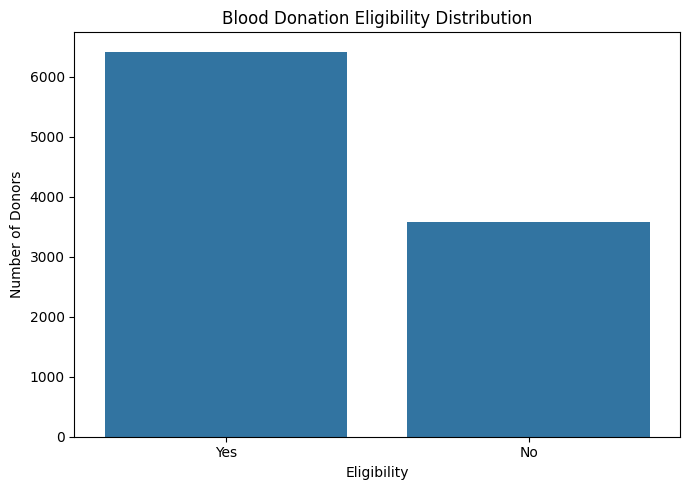

In [ ]:
# ------------------------------------------------------------
# Visualization  - Target Distribution
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

sns.countplot(
    x=data[target]
)

plt.title("Blood Donation Eligibility Distribution")
plt.xlabel("Eligibility")
plt.ylabel("Number of Donors")

plt.tight_layout()
plt.show()

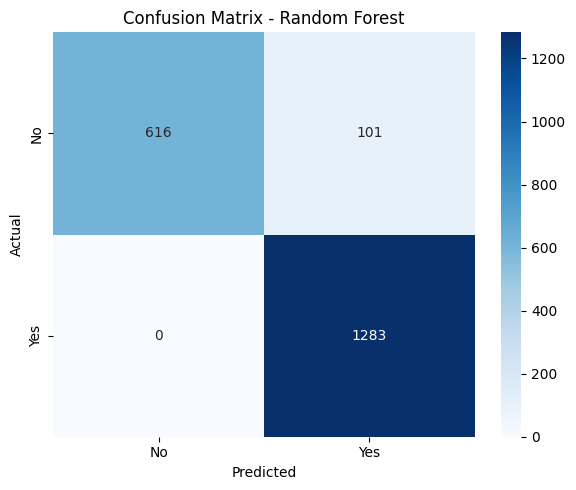

In [ ]:
# ------------------------------------------------------------
# Visualization  - Confusion Matrix
# ------------------------------------------------------------

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"]
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

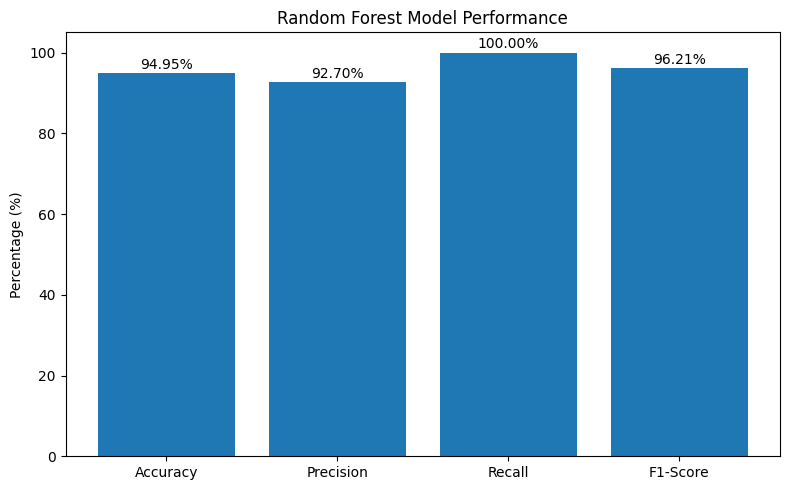

In [ ]:
# ------------------------------------------------------------
# Visualization  - Model Performance
# ------------------------------------------------------------

metrics = {
    "Accuracy": accuracy * 100,
    "Precision": precision * 100,
    "Recall": recall * 100,
    "F1-Score": f1 * 100
}

plt.figure(figsize=(8, 5))

plt.bar(
    metrics.keys(),
    metrics.values()
)

plt.ylim(0, 105)

plt.title("Random Forest Model Performance")
plt.ylabel("Percentage (%)")

for i, value in enumerate(metrics.values()):
    plt.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()


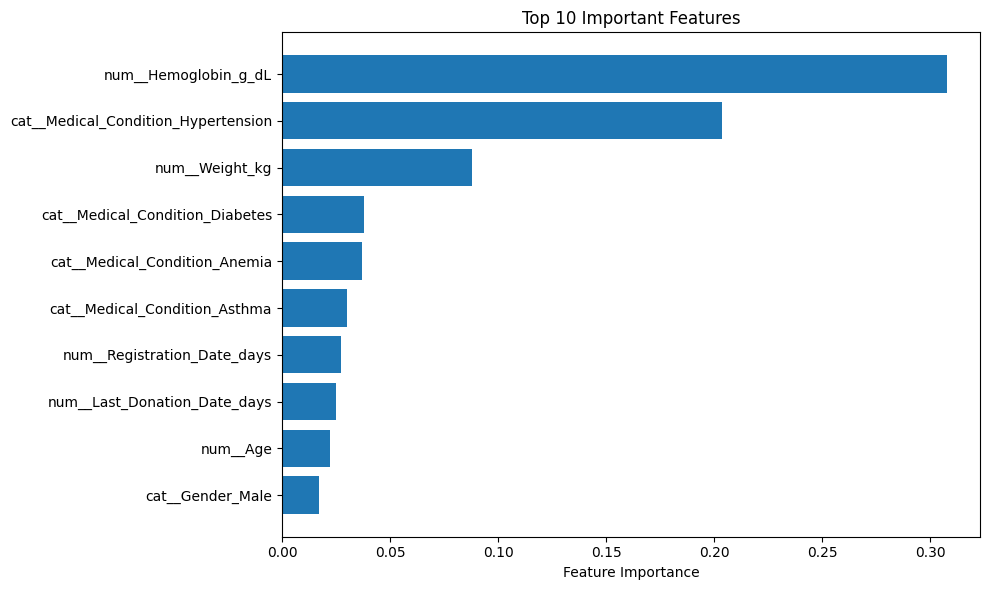

In [ ]:
# ------------------------------------------------------------
# Visualization  - Feature Importance
# ------------------------------------------------------------

feature_names = pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

importance = pipeline.named_steps[
    "model"
].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

top_features = importance_df.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.title("Top 10 Important Features")
plt.xlabel("Feature Importance")

plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------
#  Final Result
# ------------------------------------------------------------

print("\n========================================")
print("             FINAL RESULT")
print("========================================")

print(
    f"Random Forest achieved "
    f"{accuracy * 100:.2f}% accuracy."
)

print("Model Performance:")
print(f"Accuracy  : {accuracy * 100:.2f}%")
print(f"Precision : {precision * 100:.2f}%")
print(f"Recall    : {recall * 100:.2f}%")
print(f"F1-Score  : {f1 * 100:.2f}%")



             FINAL RESULT
Random Forest achieved 94.95% accuracy.
Model Performance:
Accuracy  : 94.95%
Precision : 92.70%
Recall    : 100.00%
F1-Score  : 96.21%
